# 04 User Quality Diagnosis

## Business Question

Source 4成为主要新增来源后，其Activation、短期留存和首周使用深度是否与同期主要来源存在差异？

## Analysis Objective

分别检查历史成熟用户和2015-10-07至2015-10-09同期成熟cohort，比较Source 4与Source 3/7/9，并使用两比例检验评估D7差异。本章只描述数据观察，不解释原因。

## Data Used

- `data/processed/user_growth_profile.csv`

## Key Metrics

- Activation Rate。
- D1/D3/D7 Retention。
- First 7 Active Days。
- First 7 Play Count。
- First 7 Total Seconds。
- D7差异、95%置信区间和双侧两比例z检验。


In [1]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
AS_OF_DATE = pd.Timestamp("2015-10-16")
ANALYSIS_START = pd.Timestamp("2015-07-01")
pd.set_option("display.max_columns", 50)


In [2]:
columns = ["msno", "registration_date", "registered_via", "activated_flag", "d1_retained",
           "d3_retained", "d7_retained", "first_7_active_days", "first_7_play_count",
           "first_7_total_secs", "activation_eligible_flag", "d1_eligible_flag",
           "d3_eligible_flag", "d7_eligible_flag", "first_7_eligible_flag"]
profile = pd.read_csv(PROCESSED_DIR / "user_growth_profile.csv", usecols=columns,
                      dtype={"msno": "string", "registered_via": "Int16"},
                      parse_dates=["registration_date"])
assert profile.msno.is_unique
historical = profile[profile.registration_date.le("2015-10-09")].copy()
post = historical[historical.registration_date.between("2015-10-07", "2015-10-09")].copy()
print(f"Historical mature users: {len(historical):,}")
print(f"Post-anomaly mature users: {len(post):,}")


Historical mature users: 442,029
Post-anomaly mature users: 26,892


In [3]:
def quality_summary(frame, scope):
    rows = []
    for source, group in frame[frame.registered_via.isin([3, 4, 7, 9])].groupby("registered_via"):
        rows.append({
            "scope": scope, "registered_via": int(source), "users": len(group),
            "activation_n": int(group.activation_eligible_flag.sum()),
            "activation_rate": group.loc[group.activation_eligible_flag.eq(1), "activated_flag"].mean(),
            "d1_n": int(group.d1_eligible_flag.sum()),
            "d1_retention": group.loc[group.d1_eligible_flag.eq(1), "d1_retained"].mean(),
            "d3_n": int(group.d3_eligible_flag.sum()),
            "d3_retention": group.loc[group.d3_eligible_flag.eq(1), "d3_retained"].mean(),
            "d7_n": int(group.d7_eligible_flag.sum()),
            "d7_retained_users": int(group.loc[group.d7_eligible_flag.eq(1), "d7_retained"].sum()),
            "d7_retention": group.loc[group.d7_eligible_flag.eq(1), "d7_retained"].mean(),
            "first_7_n": int(group.first_7_eligible_flag.sum()),
            "avg_first_7_active_days": group.loc[group.first_7_eligible_flag.eq(1), "first_7_active_days"].mean(),
            "avg_first_7_play_count": group.loc[group.first_7_eligible_flag.eq(1), "first_7_play_count"].mean(),
            "avg_first_7_total_secs": group.loc[group.first_7_eligible_flag.eq(1), "first_7_total_secs"].mean(),
        })
    return pd.DataFrame(rows)

historical_quality = quality_summary(historical, "historical_mature")
post_quality = quality_summary(post, "post_anomaly_2015-10-07_to_09")
display(historical_quality)
display(post_quality)


,scope,registered_via,users,activation_n,activation_rate,d1_n,d1_retention,d3_n,d3_retention,d7_n,d7_retained_users,d7_retention,first_7_n,avg_first_7_active_days,avg_first_7_play_count,avg_first_7_total_secs
0,historical_mature,3,198850,198850,0.903611,198850,0.462746,198850,0.304370,198850,50365,0.253281,198850,2.733176,88.676781,14290.485871
1,historical_mature,4,21485,21485,0.875308,21485,0.408006,21485,0.247382,21485,887,0.041285,21485,1.983756,54.345125,8327.255893
2,historical_mature,7,63607,63607,0.723961,63607,0.432578,63607,0.373214,63607,22655,0.356171,63607,2.495952,81.348499,12880.401751
3,historical_mature,9,157170,157170,0.907622,157170,0.503792,157170,0.146313,157170,18662,0.118738,157170,2.088783,75.438741,12593.249692


,scope,registered_via,users,activation_n,activation_rate,d1_n,d1_retention,d3_n,d3_retention,d7_n,d7_retained_users,d7_retention,first_7_n,avg_first_7_active_days,avg_first_7_play_count,avg_first_7_total_secs
0,post_anomaly_2015-10-07_to_09,3,1601,1601,0.838226,1601,0.430356,1601,0.266084,1601,198,0.123673,1601,2.198001,70.980012,11193.504637
1,post_anomaly_2015-10-07_to_09,4,20876,20876,0.884796,20876,0.416794,20876,0.253209,20876,873,0.041818,20876,2.018873,55.617934,8526.201981
2,post_anomaly_2015-10-07_to_09,7,2872,2872,0.741295,2872,0.441852,2872,0.370125,2872,1112,0.387187,2872,2.619081,83.847145,13449.650740
3,post_anomaly_2015-10-07_to_09,9,1519,1519,0.877551,1519,0.533904,1519,0.330481,1519,280,0.184332,1519,2.649111,107.388413,20705.389363


In [4]:
def two_proportion_test(x1, n1, x2, n2):
    p1, p2 = x1/n1, x2/n2
    diff = p1 - p2
    se_diff = math.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
    ci = (diff - 1.95996398454*se_diff, diff + 1.95996398454*se_diff)
    pooled = (x1+x2)/(n1+n2)
    se_null = math.sqrt(pooled*(1-pooled)*(1/n1+1/n2))
    z = diff/se_null
    p_value = math.erfc(abs(z)/math.sqrt(2))
    return diff, ci[0], ci[1], z, p_value

s4 = post_quality[post_quality.registered_via.eq(4)].iloc[0]
tests = []
for comparator in [3, 7, 9]:
    other = post_quality[post_quality.registered_via.eq(comparator)].iloc[0]
    result = two_proportion_test(int(s4.d7_retained_users), int(s4.d7_n),
                                 int(other.d7_retained_users), int(other.d7_n))
    tests.append({"comparison": f"Source4 - Source{comparator}", "difference_pp": result[0]*100,
                  "ci95_low_pp": result[1]*100, "ci95_high_pp": result[2]*100,
                  "z_stat": result[3], "p_value_two_sided": result[4]})
d7_tests = pd.DataFrame(tests)
display(d7_tests)


,comparison,difference_pp,ci95_low_pp,ci95_high_pp,z_stat,p_value_two_sided
0,Source4 - Source3,-8.185435,-9.820722,-6.550148,-14.817255,1.133222e-49
1,Source4 - Source7,-34.536827,-36.338880,-32.734775,-62.700670,0.000000e+00
2,Source4 - Source9,-14.251344,-16.220121,-12.282567,-24.267304,4.342376e-130


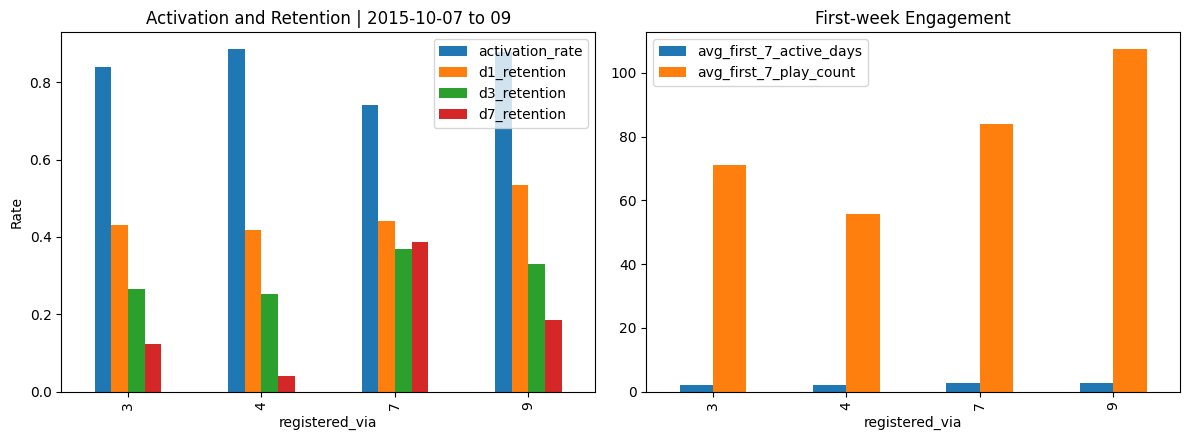

In [5]:
plot = post_quality.set_index("registered_via")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot[["activation_rate", "d1_retention", "d3_retention", "d7_retention"]].plot.bar(ax=axes[0])
axes[0].set(title="Activation and Retention | 2015-10-07 to 09", ylabel="Rate", xlabel="registered_via")
plot[["avg_first_7_active_days", "avg_first_7_play_count"]].plot.bar(ax=axes[1])
axes[1].set(title="First-week Engagement", xlabel="registered_via")
fig.tight_layout(); plt.show()


## User-quality Conclusion

同期cohort中，Source 4的Activation不低；D1开始落后，D7明显低于Source 3/7/9。Source 4首周活跃天数、播放次数和播放时长也较低。D7差异的95%置信区间不跨0。

这些结果说明首次活动后的持续使用存在风险，但不能确定差异原因。统计显著不等于因果关系成立。
